# Dyna-Q: learn from experience and planning

Dyna-Q applies the Q-Learning update to real transitions and to transitions replayed from a learned model:

$$Q(S,A)\leftarrow Q(S,A)+\alpha\left[R+\gamma(1-d)\max_aQ(S',a)-Q(S,A)\right].$$

Here $\alpha$ is the learning rate, $\gamma$ the discount factor, $d$ the terminal indicator, and $(S,A,R,S')$ a transition. The model stores the latest outcome for each observed state-action pair, then planning samples those pairs uniformly.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

ENV_ID = "FrozenLake-v1"
TOTAL_TIMESTEPS = 5_000
LEARNING_RATE = 0.2
GAMMA = 0.99
PLANNING_STEPS = 10
EPSILON_START = 1.0
EPSILON_END = 0.05
EXPLORATION_STEPS = 3_000
SEED = 7

env = gym.make(ENV_ID, is_slippery=False)
rng = np.random.default_rng(SEED)
q_table = np.zeros((env.observation_space.n, env.action_space.n))
model = {}

## 1. Choose actions and update values

The behavior policy is epsilon-greedy. `q_update` is shared by real experience and planning, making the connection between the two data sources explicit.

In [2]:
def epsilon_at(step):
    fraction = min(step / EXPLORATION_STEPS, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def select_action(state, step, deterministic=False):
    if not deterministic and rng.random() < epsilon_at(step):
        return int(rng.integers(q_table.shape[1]))
    return int(np.argmax(q_table[state]))


def q_update(state, action, reward, next_state, terminated):
    target = reward + GAMMA * (1 - terminated) * q_table[next_state].max()
    td_error = target - q_table[state, action]
    q_table[state, action] += LEARNING_RATE * td_error
    return td_error

## 2. Interleave collection and planning

Each real step updates the table once and updates the deterministic model. Then `PLANNING_STEPS` stored transitions receive the same TD update. `terminated` disables bootstrapping; `truncated` only ends collection and still bootstraps.

In [3]:
def train(total_timesteps):
    episode_returns = []
    episode_return = 0.0
    state, _ = env.reset(seed=SEED)

    for step in range(total_timesteps):
        action = select_action(state, step)
        next_state, reward, terminated, truncated, _ = env.step(action)
        q_update(state, action, reward, next_state, terminated)
        model[(state, action)] = (reward, next_state, terminated)

        keys = list(model)
        for _ in range(PLANNING_STEPS):
            planned_state, planned_action = keys[rng.integers(len(keys))]
            planned_reward, planned_next_state, planned_terminal = model[(planned_state, planned_action)]
            q_update(planned_state, planned_action, planned_reward, planned_next_state, planned_terminal)

        episode_return += reward
        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            state, _ = env.reset()
        else:
            state = next_state
    return episode_returns


episode_returns = train(TOTAL_TIMESTEPS)
env.close()
print("Learned model entries:", len(model))

Learned model entries: 43


## 3. Plot learning

Because FrozenLake rewards are sparse, a moving average makes the improving success rate easier to see.

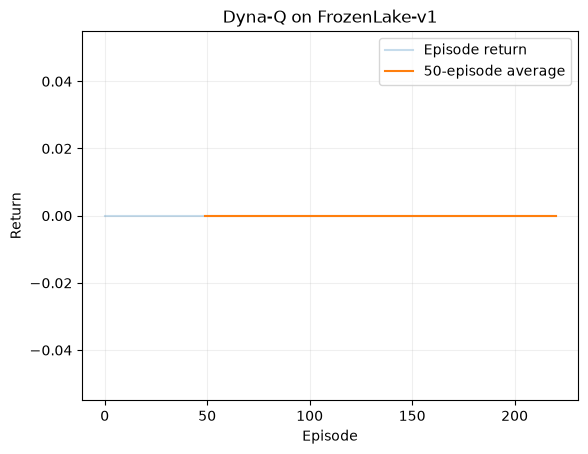

In [4]:
window = min(50, len(episode_returns))
moving_average = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
plt.plot(episode_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window - 1, len(episode_returns)), moving_average, label=f"{window}-episode average")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Dyna-Q on FrozenLake-v1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4. Evaluate the greedy policy

This opens a separate rendered environment and disables exploration for 5 episodes.

In [5]:
evaluation_env = gym.make(ENV_ID, render_mode="human", is_slippery=False)
evaluation_returns = []
try:
    for episode in range(5):
        state, _ = evaluation_env.reset(seed=10 + episode)
        total_reward = 0.0
        done = False
        while not done:
            action = select_action(state, TOTAL_TIMESTEPS, deterministic=True)
            state, reward, terminated, truncated, _ = evaluation_env.step(action)
            total_reward += reward
            done = terminated or truncated
        evaluation_returns.append(total_reward)
finally:
    evaluation_env.close()
print("Episode returns:", evaluation_returns)

Episode returns: [0.0, 0.0, 0.0, 0.0, 0.0]
